In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import time

# 📥 Cargar datos
ruta = r'C:\Users\jthow\iCloudDrive\Documents\3_Maestria_Estadistica_UNINORTE\3_Tercer_Semestre\Machine_Learning\tornados.csv.zip'  
df = pd.read_csv(ruta)

## Hist_Gradient_Boosting_Regressor

In [3]:
# 🧹 Preprocesamiento
df_modelo = df.copy()
df_modelo = df_modelo.drop(columns=['fat', 'date', 'time', 'datetime_utc'], errors='ignore')

# Codificar variables categóricas
df_modelo = pd.get_dummies(df_modelo, columns=['st', 'tz'], drop_first=True)

# Variables predictoras y objetivo
X = df_modelo.drop(columns=['inj'])
y = df_modelo['inj']

# 🧪 División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [4]:
# ⚖️ Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 🚀 Modelo
start = time.time()
model = HistGradientBoostingRegressor()
model.fit(X_train_scaled, y_train)
training_time = round(time.time() - start, 4)

In [6]:
# 🔮 Predicciones
y_pred = model.predict(X_test_scaled)

# 📊 Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [7]:
# 📋 Resultados
resultados_hgb = pd.DataFrame({
    'Modelo': ['HistGradientBoosting'],
    'MAE': [round(mae, 2)],
    'RMSE': [round(rmse, 2)],
    'R²': [round(r2, 4)],
    'CPU time (s)': [training_time]
})

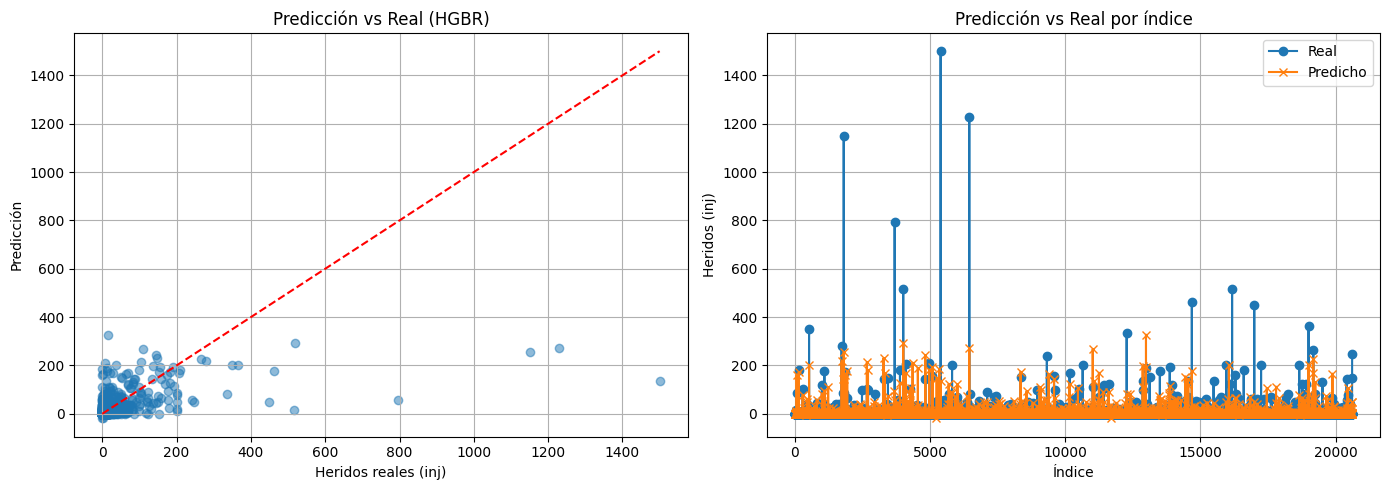

,Modelo,MAE,RMSE,R²,CPU time (s)
0,HistGradientBoosting,1.58,17.13,0.3089,193.9889


In [8]:
# 📈 Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scatter
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("Heridos reales (inj)")
axes[0].set_ylabel("Predicción")
axes[0].set_title("Predicción vs Real (HGBR)")
axes[0].grid(True)

# Gráfico 2: Índice
axes[1].plot(y_test.values, label="Real", marker='o')
axes[1].plot(y_pred, label="Predicho", marker='x')
axes[1].set_title("Predicción vs Real por índice")
axes[1].set_xlabel("Índice")
axes[1].set_ylabel("Heridos (inj)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

resultados_hgb

## Aplicación de Pipeline y Gridsearch

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

In [10]:
# 🧪 Pipeline
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

In [11]:
# 🎯 Parámetros a probar
param_grid = {
    "model__learning_rate": [0.01, 0.1],
    "model__max_iter": [100, 200],
    "model__max_depth": [None, 10, 20]
}

In [12]:
# 🕒 Entrenamiento con tiempo
start = time.process_time()
grid = GridSearchCV(pipe, param_grid, cv=3, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)
end = time.process_time()

tiempo_hgbr_pg = round(end - start, 4)

In [13]:
# ✅ Predicción
y_pred_hgbr_pg = grid.predict(X_test)

# 📈 Métricas
mae_hgbr_pg = mean_absolute_error(y_test, y_pred_hgbr_pg)
rmse_hgbr_pg = np.sqrt(mean_squared_error(y_test, y_pred_hgbr_pg))
r2_hgbr_pg = r2_score(y_test, y_pred_hgbr_pg)

In [14]:
# 📄 Resultados
resultados_hgbr_pg = pd.DataFrame({
    "Modelo": ["HistGradientBoosting PG"],
    "MAE": [round(mae_hgbr_pg, 2)],
    "RMSE": [round(rmse_hgbr_pg, 2)],
    "R²": [round(r2_hgbr_pg, 4)],
    "CPU time (s)": [tiempo_hgbr_pg]
})

display(resultados_hgbr_pg)

,Modelo,MAE,RMSE,R²,CPU time (s)
0,HistGradientBoosting PG,1.56,16.84,0.3325,527.5625


In [15]:
# 🏆 Mostrar mejores hiperparámetros encontrados
print("🎯 Mejores hiperparámetros encontrados por GridSearchCV:")
for param, val in grid.best_params_.items():
    print(f"  {param}: {val}")


🎯 Mejores hiperparámetros encontrados por GridSearchCV:
  model__learning_rate: 0.1
  model__max_depth: 10
  model__max_iter: 100


C:\Users\jthow\AppData\Local\Temp\ipykernel_24316\4031945973.py:23: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.tight_layout()


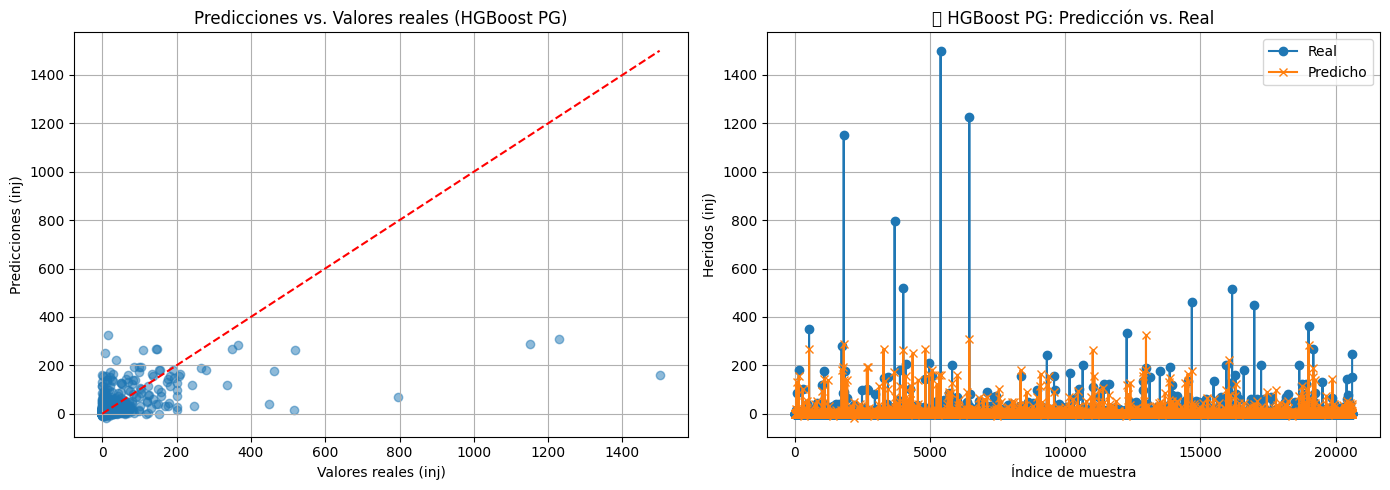

In [17]:
import matplotlib.pyplot as plt

# 🔹 Crear figura y ejes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔹 Gráfico 1: Dispersión (scatter)
axes[0].scatter(y_test, y_pred_hgbr_pg, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Valores reales (inj)')
axes[0].set_ylabel('Predicciones (inj)')
axes[0].set_title('Predicciones vs. Valores reales (HGBoost PG)')
axes[0].grid(True)

# 🔹 Gráfico 2: Línea Real vs. Predicho
axes[1].plot(y_test.values, label='Real', marker='o')
axes[1].plot(y_pred_hgbr_pg, label='Predicho', marker='x')
axes[1].set_title("🔁 HGBoost PG: Predicción vs. Real")
axes[1].set_xlabel("Índice de muestra")
axes[1].set_ylabel("Heridos (inj)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
